In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import json, os, math
import joblib
from itertools import product
from scipy.signal import butter, filtfilt

import matplotlib.ticker as mticker
import pandas as pd
import control as ctl
from tqdm import tqdm

In [2]:
OPTIONS = json.loads(open('info.json', 'r').read())
OPTIONS

{'dt': 0.045,
 'offset': 3,
 'view_range': [0.7, 0.8],
 'sensor_range': [400, 900],
 'actuator_range': [0, 255],
 'sensor_filter': {'num': [0.3612210092368324, 0.36122100923683254],
  'den': [1.0, -0.27755798152633504]},
 'Fc': 4.0,
 'ts': 0.432}

# EXTRAINDO DADOS

In [3]:
df   = pd.read_csv('../Dataset/data_cleaned.csv')
K_CV = 5
TEMPORAL = True

X_MIN, X_MAX = OPTIONS.get('view_range')
dt = OPTIONS.get('dt')
ts = OPTIONS.get('ts')

SENSOR_RANGE   = OPTIONS.get('sensor_range')
ACTUATOR_RANGE = OPTIONS.get('actuator_range')

OFFSET = OPTIONS.get('offset')
df

,time,input,sensor
0,0.000,255,364.110777
1,0.045,255,717.666115
2,0.090,255,630.491843
3,0.135,255,524.298759
4,0.180,255,470.983435
...,...,...,...
2172,97.740,122,475.655785
2173,97.785,122,489.630859
2174,97.830,122,478.338470
2175,97.875,122,466.896094


Text(0, 0.5, 'sensor')

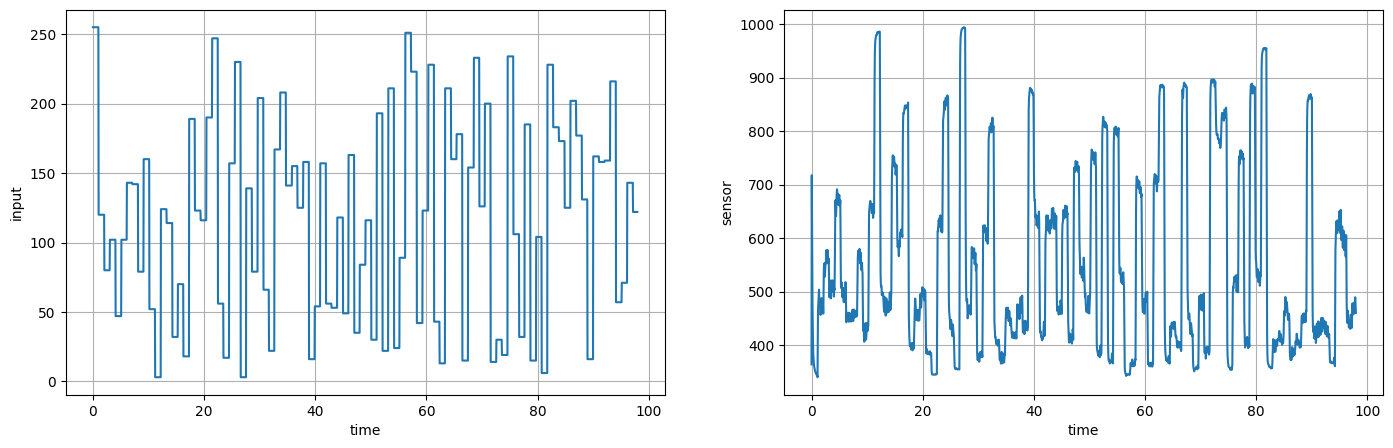

In [4]:
plt.figure(figsize=(17, 5))
plt.subplot(1, 2, 1)
plt.plot(df.time, df.input)
plt.grid()
plt.xlabel('time'); plt.ylabel('input')

plt.subplot(1, 2, 2)
plt.plot(df.time, df.sensor)
plt.grid()
plt.xlabel('time'); plt.ylabel('sensor')

# MÉTRICAS DE ERRO

In [5]:
df['delta_u'] = df.input.diff()
df['error']   = df.sensor.shift(-OFFSET) - df.sensor
df = df.dropna()

In [6]:
def getStates(df, key, var='y', n=10, last=True):
    table = df.copy() 
    table[f'{var}'] = table[key]

    for i in range(1, n):
        table[f'{var}(n-{i})'] = table[key].shift(i)

    table.fillna(0, inplace=True)
    columns = [f'{var}'] + [f'{var}(n-{i})' for i in range(1, n)]

    if not last:
        columns = columns[1:]

    return table[columns]


N_STATES = 5
xData = pd.concat([
    getStates(df, 'input',  var='u', n=N_STATES, last=False),
    getStates(df, 'sensor', var='x', n=N_STATES, last=True),
    df.error
], axis=1)

xData = xData.iloc[N_STATES:].reset_index(drop=True)
yData = df.delta_u.values[N_STATES:]
xData

,u(n-1),u(n-2),u(n-3),u(n-4),x,x(n-1),x(n-2),x(n-3),x(n-4),error
0,255.0,255.0,255.0,255.0,403.358710,431.622312,470.983435,524.298759,630.491843,-36.229253
1,255.0,255.0,255.0,255.0,384.316070,403.358710,431.622312,470.983435,524.298759,-21.976012
2,255.0,255.0,255.0,255.0,373.973540,384.316070,403.358710,431.622312,470.983435,-14.768922
3,255.0,255.0,255.0,255.0,367.129457,373.973540,384.316070,403.358710,431.622312,-10.601210
4,255.0,255.0,255.0,255.0,362.340059,367.129457,373.973540,384.316070,403.358710,-8.360766
...,...,...,...,...,...,...,...,...,...,...
2163,122.0,122.0,122.0,122.0,474.109457,479.600060,469.449098,457.603779,459.175327,1.546328
2164,122.0,122.0,122.0,122.0,466.805961,474.109457,479.600060,469.449098,457.603779,22.824898
2165,122.0,122.0,122.0,122.0,460.444165,466.805961,474.109457,479.600060,469.449098,17.894305
2166,122.0,122.0,122.0,122.0,475.655785,460.444165,466.805961,474.109457,479.600060,-8.759691


# MODELO

In [7]:
import importlib
import Neural.index
importlib.reload(Neural.index)
from Neural.index import NeuralSelector

In [8]:
selector = NeuralSelector()
model    = selector.get()
model.fit(xData, yData)
model

Training RL Agent: 100%|██████████| 500/500 [04:14<00:00,  1.97it/s]


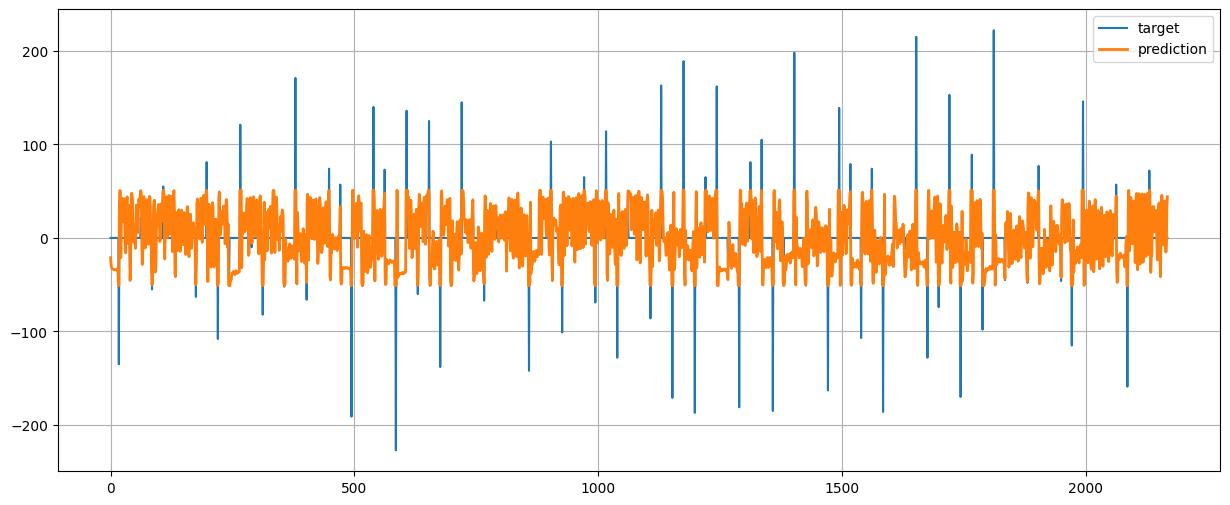

In [9]:
plt.figure(figsize=(15, 6))
plt.plot(yData, label='target')
plt.plot(model.predict(xData), label='prediction', linewidth=2)
plt.grid(); plt.legend()
plt.show()

### SALVANDO MODELO

In [12]:
results = {
    'model': selector.chosen,
    'K_CV': K_CV,
    'info': {'r2': 0, 'r2_adj': 0, 'rmse': 0, 'mae': 0},
    'variables': xData.columns.tolist()
}

display(pd.DataFrame([results.get('info')]))
results

,r2,r2_adj,rmse,mae
0,0,0,0,0


{'model': 'PPO',
 'K_CV': 5,
 'info': {'r2': 0, 'r2_adj': 0, 'rmse': 0, 'mae': 0},
 'variables': ['u(n-1)',
  'u(n-2)',
  'u(n-3)',
  'u(n-4)',
  'x',
  'x(n-1)',
  'x(n-2)',
  'x(n-3)',
  'x(n-4)',
  'error']}

In [13]:
os.makedirs('Backup/Controller', exist_ok=True)
index  = len(os.listdir('Backup/Controller')) + 1

output = f'Backup/Controller/model_{index}'
os.makedirs(output, exist_ok=True)

pd.Series(results).to_json(os.path.join(output, 'info.json'), indent=4)
joblib.dump(model, os.path.join(output, 'model.pkl'))

['Backup/Controller/model_15/model.pkl']

In [14]:
with open('info.json', 'w', encoding='utf-8') as file:
    json.dump(OPTIONS, file, ensure_ascii=False, indent=4)

# SIMULAÇÃO

### SYSTEM IDENTIFICATION

In [15]:
def getSavedModels(base):
    df = []

    for path in os.listdir(base):
        index = int(path.split('_')[-1])
        
        with open(f'{base}/{path}/info.json', 'r', encoding='utf-8') as file:
            data = json.loads(file.read())
        
        name = data['model']
        data = data['info']
        data['name'] = name
        data['id']   = index
        df.append(data)

    return pd.DataFrame(df).sort_values(by='id', ascending=False)


df = getSavedModels('Backup/System')
df

,r2,r2_adj,rmse,mae,name,id
0,0.993198,0.992902,13.838944,7.374144,linear_regression,1


In [16]:
def loadModel(base, id):
    with open(f'{base}/model_{id}/info.json', 'r', encoding='utf-8') as file:
        data = json.loads(file.read())

    data['model'] = joblib.load(f'{base}/model_{id}/model.pkl')
    return data


id   = df.iloc[0].id
data = loadModel('Backup/System', id)

sys_variables = data['variables']
N_STATES_SYS  = sum(['x(n-' in var for var in sys_variables]) + 1

print(f'System {id} Carregado  ({N_STATES_SYS} estados): {sys_variables}')
sys_model = data.get('model')
sys_model

System 1 Carregado  (8 estados): ['u', 'u(n-1)', 'u(n-2)', 'u(n-3)', 'u(n-4)', 'u(n-5)', 'u(n-6)', 'u(n-7)', 'x(n-1)', 'x(n-2)', 'x(n-3)', 'x(n-4)', 'x(n-5)', 'x(n-6)', 'x(n-7)']


,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None


### MODEL CONTROLLER

In [17]:
df = getSavedModels('Backup/Controller')
df

,r2,r2_adj,rmse,mae,name,id
2,0.000000,0.000000,0.000000,0.00000,PPO,15
14,0.000000,0.000000,0.000000,0.00000,rl_agent,14
13,0.000000,0.000000,0.000000,0.00000,rl_agent,13
4,0.000000,0.000000,0.000000,0.00000,rl_agent,12
9,0.000000,0.000000,0.000000,0.00000,rl_agent,11
7,0.000000,0.000000,0.000000,0.00000,rl_agent,10
10,0.000000,0.000000,0.000000,0.00000,rl_agent,9
0,0.000000,0.000000,0.000000,0.00000,rl_agent,8
5,0.000000,0.000000,0.000000,0.00000,rl_agent,7
1,0.000000,0.000000,0.000000,0.00000,rl_agent,6


In [18]:
id   = df.iloc[0].id
data = loadModel('Backup/Controller', id)

ctl_variables = data['variables']
N_STATES_CTL  = sum(['u(n-' in var for var in ctl_variables]) + 1

print(f'Controller {id} Carregado  ({N_STATES_CTL} estados): {ctl_variables}')
ctl_model = data.get('model')
ctl_model

Controller 15 Carregado  (5 estados): ['u(n-1)', 'u(n-2)', 'u(n-3)', 'u(n-4)', 'x', 'x(n-1)', 'x(n-2)', 'x(n-3)', 'x(n-4)', 'error']


In [37]:
class StatesUpdater:
    def __init__(self, size, initial=0.00):
        self.size   = size
        self.buffer = np.array([initial for i in range(size)])

    def update(self, value):
        for i in range(self.size-1, 0, -1):
            self.buffer[i] = self.buffer[i-1]
        self.buffer[0] = value
        return self.buffer

    def get(self, var='x'):
        data = {}
        data[var] = self.buffer[0]
        for i in range(1, self.size):
            data[f'{var}(n-{i})'] = self.buffer[i]
        return {key: float(val) for key, val in data.items()}

class System:
    def __init__(self, model, columns, n_states, init_x=0.0, init_u=0.0):
        self.n_states = n_states
        self.sensor   = StatesUpdater(self.n_states, initial=init_x)     
        self.actuator = StatesUpdater(self.n_states, initial=init_u)   
        self.model = model
        self.cols  = columns

    def update(self, actuatorValue):
        self.actuator.update(actuatorValue)
        data = self.actuator.get('u')

        for i in range(1, self.n_states):
            data[f'x(n-{i})'] = self.sensor.buffer[i-1]
        
        response = self.model.predict(pd.DataFrame([data], columns=self.cols))[0]
        self.sensor.update(response)
        return self.sensor.buffer[0]

class Controller:
    def __init__(self, model, columns, n_states, init_x=0.0, init_u=0.0):
        self.n_states = n_states
        self.sensor   = StatesUpdater(n_states, initial=init_x)     
        self.actuator = StatesUpdater(n_states, initial=init_u)
        self.error = StatesUpdater(1, initial=0.0)
        self.model = model
        self.cols  = columns

    def update(self, setpoint, sensorValue):
        self.sensor.update(sensorValue)
        self.error.update(setpoint - self.sensor.buffer[0])

        data = {}
        for i in range(1, self.n_states):
            data[f'u(n-{i})'] = self.actuator.buffer[i-1]

        data['x'] = self.sensor.buffer[0]
        for i in range(1, self.n_states):
            data[f'x(n-{i})'] = self.sensor.buffer[i]
        
        data['error'] = self.error.buffer[0]
        deltaU   = self.model.predict(pd.DataFrame([data], columns=self.cols))[0]
        response = self.actuator.buffer[0] + deltaU 
        response = np.clip(response, ACTUATOR_RANGE[0], ACTUATOR_RANGE[1])
        self.actuator.update(response)        
        return response

Starting Simulation with x=273.9199 and u=58.4665


100%|██████████| 460/460 [00:00<00:00, 832.88it/s]


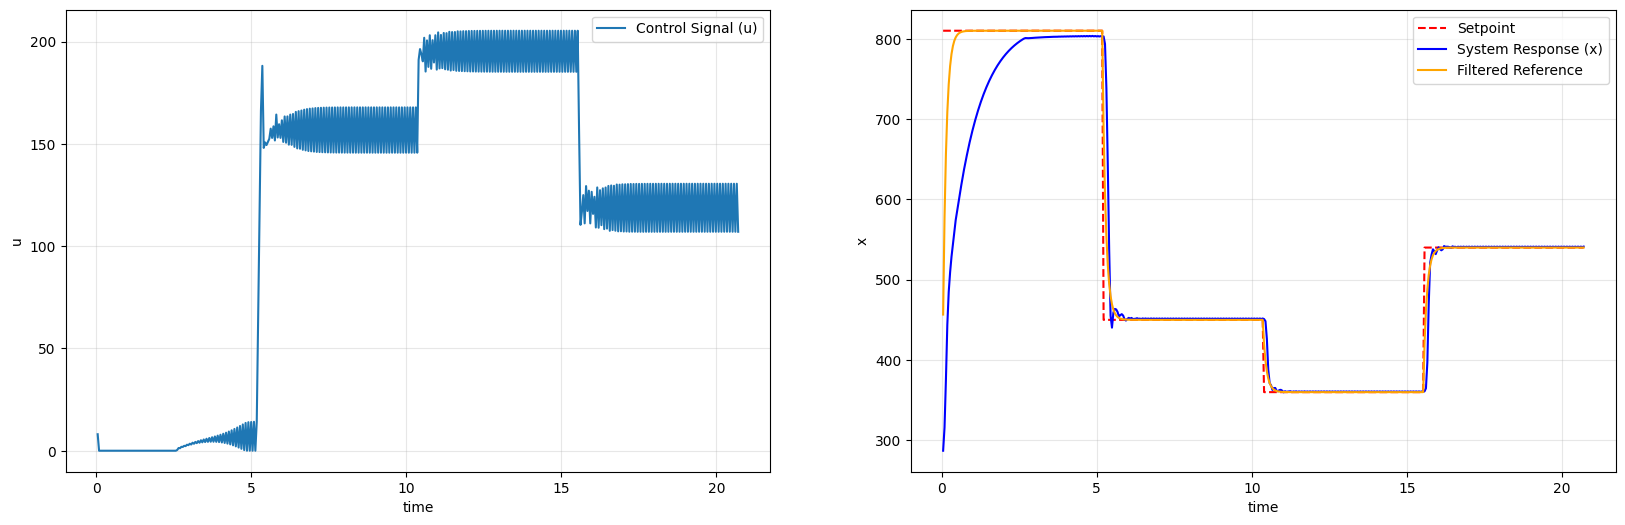

,setpoint,ref,u,x,t,error
0,810.0,456.594194,8.062678,287.052514,0.045,522.947486
1,810.0,577.020534,0.000000,315.951001,0.090,494.048999
2,810.0,656.410470,0.000000,375.436602,0.135,434.563398
3,810.0,708.747541,0.000000,443.800777,0.180,366.199223
4,810.0,743.250265,0.000000,484.569322,0.225,325.430678


In [38]:
df_data = pd.read_csv('../Dataset/data_cleaned.csv')
x_min, x_max = SENSOR_RANGE
y_min, y_max = ACTUATOR_RANGE

STEP = int(12*ts/dt)
init_x_val = np.mean(df_data.sensor.values) * 0.5
init_u_val = np.mean(df_data.input.values)  * 0.5

sim_system     = System(sys_model, sys_variables, N_STATES_SYS, init_x=init_x_val, init_u=init_u_val)          
sim_controller = Controller(ctl_model, xData.columns.tolist(), N_STATES, init_x=init_x_val, init_u=init_u_val)

setpointPath = [x_max*0.9]*STEP + [x_max*0.5]*STEP + [x_max*0.4]*STEP + [x_max*0.6]*STEP
history = []

print(f'Starting Simulation with x={init_x_val:.4f} and u={init_u_val:.4f}')
alpha = math.exp(-4 * (dt / ts))
t   = 0
x   = init_x_val
ref = init_x_val

for setpoint in tqdm(setpointPath):
    ref = alpha * ref + (1 - alpha) * setpoint
    u = sim_controller.update(ref, x)
    x = sim_system.update(u)
    t = t + dt
    history.append({'setpoint': setpoint, 'ref': ref, 'u': u, 'x': x, 't': t, 'error': setpoint - x})

history_df = pd.DataFrame(history)
plt.figure(figsize=(20, 6))
plt.subplot(1, 2, 1)
plt.plot(history_df.t, history_df.u, label='Control Signal (u)')
plt.xlabel('time'); plt.ylabel('u'); plt.legend()
plt.grid(alpha=.3)

plt.subplot(1, 2, 2)
plt.plot(history_df.t, history_df.setpoint, linestyle='--', color='red', label='Setpoint')
plt.plot(history_df.t, history_df.x, label='System Response (x)', color='blue')
plt.plot(history_df.t, history_df.ref, label='Filtered Reference', color='orange')
plt.xlabel('time'); plt.ylabel('x'); plt.grid(alpha=.3); plt.legend()
plt.show()
display(history_df.head())